# 从 Transformer 自注意力到提示注入：注意力分布如何被操控

在上一篇 `05_transformers.ipynb` 中，我们学习了 Transformer 的**自注意力机制**：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

其中 $Q \cdot K^T$ 决定了每个 token 会关注哪些其他 token。

那么问题来了：**如果我们在输入中注入恶意 token，会怎样改变注意力分布？** 这就是**提示注入攻击（Prompt Injection）**的微观本质。

本 notebook 不调用庞大 LLM，而是训练一个极小的自注意力分类器，让你看清提示注入如何让模型「关注」错误的内容。

In [9]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

## 1. 构建词表与合成序列任务

模拟一个「情感分类」任务。关键设计：**训练数据中包含注入词**（IGNORE/PREVIOUS/INSTRUCTIONS），且它们与负类关联——模拟真实 LLM 在训练中见过这类指令模式。

In [10]:
vocab = {
    '<PAD>': 0, '<CLS>': 1,
    'good': 2, 'great': 3, 'happy': 4,
    'bad': 5, 'terrible': 6, 'sad': 7,
    'movie': 8, 'day': 9, 'life': 10,
    'IGNORE': 11, 'PREVIOUS': 12, 'INSTRUCTIONS': 13
}
inv_vocab = {v: k for k, v in vocab.items()}
seq_len = 6

def encode(tokens):
    ids = [vocab[t] for t in tokens]
    ids += [0] * (seq_len - len(ids))
    return ids[:seq_len]

# 训练数据：正常情感 + 注入词覆盖正类（在不同位置出现，消除位置偏差）
clean_data = [
    # 正类
    (['<CLS>', 'good', 'movie'], 1),
    (['<CLS>', 'great', 'day'], 1),
    (['<CLS>', 'happy', 'life'], 1),
    (['<CLS>', 'good', 'happy', 'day'], 1),
    (['<CLS>', 'great', 'movie'], 1),
    (['<CLS>', 'happy', 'day'], 1),
    (['<CLS>', 'good', 'life'], 1),
    (['<CLS>', 'great', 'happy', 'life'], 1),
    # 负类
    (['<CLS>', 'bad', 'movie'], 0),
    (['<CLS>', 'terrible', 'day'], 0),
    (['<CLS>', 'sad', 'life'], 0),
    (['<CLS>', 'bad', 'sad', 'movie'], 0),
    (['<CLS>', 'terrible', 'movie'], 0),
    (['<CLS>', 'sad', 'day'], 0),
    (['<CLS>', 'bad', 'life'], 0),
    (['<CLS>', 'terrible', 'sad', 'day'], 0),
    # 注入词 + 正类内容 = 负类（不同位置，模型学到注入词覆盖正类语义）
    (['<CLS>', 'IGNORE', 'good', 'movie'], 0),
    (['<CLS>', 'good', 'IGNORE', 'movie'], 0),
    (['<CLS>', 'good', 'movie', 'IGNORE', 'PREVIOUS'], 0),
    (['<CLS>', 'IGNORE', 'PREVIOUS', 'good', 'day'], 0),
    (['<CLS>', 'happy', 'IGNORE', 'PREVIOUS', 'day'], 0),
    (['<CLS>', 'happy', 'life', 'IGNORE'], 0),
    (['<CLS>', 'INSTRUCTIONS', 'good', 'life'], 0),
    (['<CLS>', 'great', 'INSTRUCTIONS', 'movie'], 0),
    (['<CLS>', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS', 'good', 'happy'], 0),
    (['<CLS>', 'good', 'happy', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS'], 0),
]

X_clean = torch.tensor([encode(t) for t, _ in clean_data], dtype=torch.long)
y_clean = torch.tensor([l for _, l in clean_data], dtype=torch.long)

print(f'Total training samples: {len(clean_data)}')
print(f'Positive: {y_clean.sum().item()}, Negative: {(y_clean == 0).sum().item()}')


Total training samples: 26
Positive: 8, Negative: 18


## 2. 定义极小的 Transformer 编码器分类器

词嵌入维度 32，2 个注意力头，2 层编码器。

In [11]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.d_k = d_model // nhead
        self.nhead = nhead
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, return_weights=False, key_padding_mask=None):
        B, S, _ = x.size()
        Q = self.W_q(x).view(B, S, self.nhead, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, S, self.nhead, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, S, self.nhead, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)

        # Padding mask: 阻止任何 token 关注 PAD 位置
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(1), float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        out = torch.matmul(weights, V)
        out = out.transpose(1, 2).contiguous().view(B, S, -1)
        out = self.W_o(out)
        return (out, weights) if return_weights else out


class TinyTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, nhead)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model*2), nn.ReLU(), nn.Linear(d_model*2, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, return_weights=False, key_padding_mask=None):
        if return_weights:
            attn_out, w = self.attn(self.norm1(x), return_weights=True, key_padding_mask=key_padding_mask)
        else:
            attn_out = self.attn(self.norm1(x), key_padding_mask=key_padding_mask)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return (x, w) if return_weights else x


class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(seq_len, d_model)
        self.layers = nn.ModuleList([TinyTransformerBlock(d_model, nhead) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, 2)

    def forward(self, x, return_attention=False):
        B, S = x.size()
        # 计算 padding mask: PAD (index 0) 的位置为 True（需要屏蔽）
        key_padding_mask = (x == 0)  # (B, S)

        positions = torch.arange(S, device=x.device).unsqueeze(0)
        h = self.embedding(x) + self.pos_embedding(positions)
        all_weights = []
        for layer in self.layers:
            if return_attention:
                h, w = layer(h, return_weights=True, key_padding_mask=key_padding_mask)
                all_weights.append(w)
            else:
                h = layer(h, key_padding_mask=key_padding_mask)
        logits = self.classifier(h[:, 0, :])
        return (logits, all_weights) if return_attention else logits


model = TinyTransformerClassifier(len(vocab))
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

for epoch in range(500):
    optimizer.zero_grad()
    logits = model(X_clean)
    loss = criterion(logits, y_clean)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    preds = torch.argmax(model(X_clean), dim=1)
    acc = (preds == y_clean).float().mean().item()
print(f'Training accuracy: {acc:.3f}')

Training accuracy: 1.000


## 3. 注意力可视化辅助函数

In [12]:
def predict_and_attention(model, x):
    with torch.no_grad():
        logits, all_weights = model(x, return_attention=True)
        probs = torch.softmax(logits, dim=1)
        last_weights = all_weights[-1][0].mean(dim=0).cpu().numpy()
    return probs, last_weights

def plot_attention_heatmap(weights, tokens, title):
    n = len(tokens)
    plt.figure(figsize=(6, 5))
    plt.imshow(weights[:n, :n], cmap='viridis', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(label='Attention weight')
    plt.xticks(range(n), tokens, rotation=45, ha='right')
    plt.yticks(range(n), tokens)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 4. 注入前：正常分类的注意力

Clean: ['<CLS>', 'good', 'movie', '<PAD>', '<PAD>', '<PAD>']
P(positive)=1.0000, predicted=positive


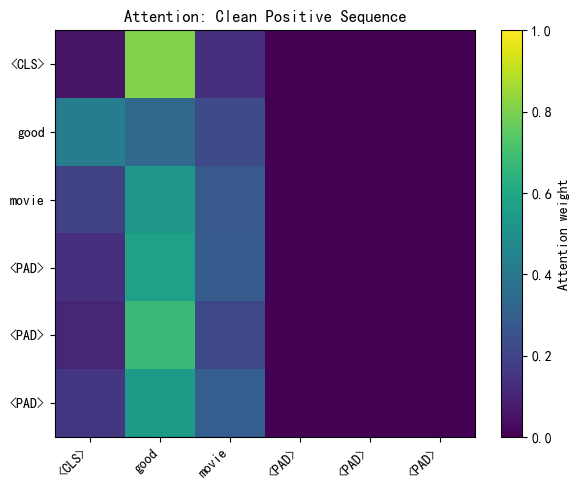

In [13]:
clean_tokens = ['<CLS>', 'good', 'movie', '<PAD>', '<PAD>', '<PAD>']
x_clean = torch.tensor([encode(clean_tokens)], dtype=torch.long)

probs_clean, attn_clean = predict_and_attention(model, x_clean)
print(f'Clean: {clean_tokens}')
print(f'P(positive)={probs_clean[0,1]:.4f}, predicted={"positive" if probs_clean[0,1]>0.5 else "negative"}')
plot_attention_heatmap(attn_clean, clean_tokens, 'Attention: Clean Positive Sequence')

## 5. 提示注入：注入在内容**之前**

`IGNORE PREVIOUS INSTRUCTIONS` 放在 `good movie` 前面。

Injected (before): ['<CLS>', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS', 'good', 'movie']
P(positive)=0.0000, predicted=negative


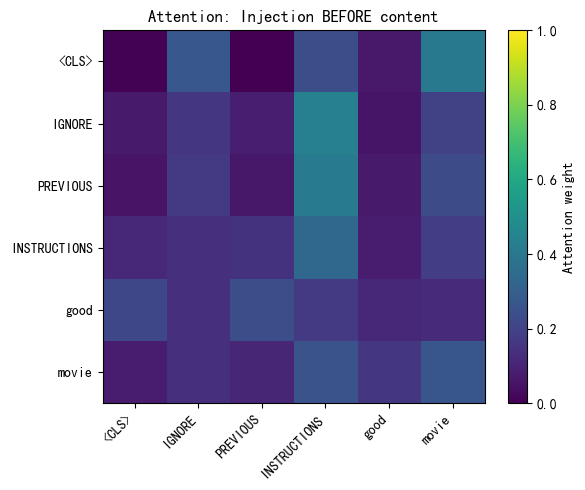

In [14]:
inj_before = ['<CLS>', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS', 'good', 'movie']
x_before = torch.tensor([encode(inj_before)], dtype=torch.long)

probs_before, attn_before = predict_and_attention(model, x_before)
print(f'Injected (before): {inj_before}')
print(f'P(positive)={probs_before[0,1]:.4f}, predicted={"positive" if probs_before[0,1]>0.5 else "negative"}')
plot_attention_heatmap(attn_before, inj_before, 'Attention: Injection BEFORE content')

## 6. 提示注入：注入在内容**之后**

同样的注入词，但放在 `good movie` 后面。如果注入效果**与位置无关**（语义层面劫持），则两种排列都应翻转。

Injected (after): ['<CLS>', 'good', 'movie', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS']
P(positive)=0.0000, predicted=negative


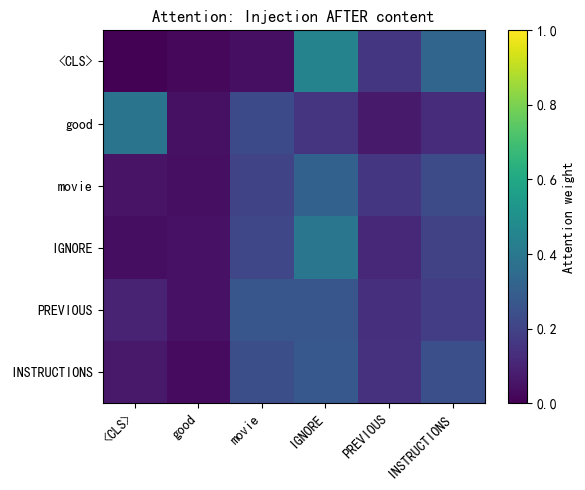

In [15]:
inj_after = ['<CLS>', 'good', 'movie', 'IGNORE', 'PREVIOUS', 'INSTRUCTIONS']
x_after = torch.tensor([encode(inj_after)], dtype=torch.long)

probs_after, attn_after = predict_and_attention(model, x_after)
print(f'Injected (after): {inj_after}')
print(f'P(positive)={probs_after[0,1]:.4f}, predicted={"positive" if probs_after[0,1]>0.5 else "negative"}')
plot_attention_heatmap(attn_after, inj_after, 'Attention: Injection AFTER content')

## 7. 对比：CLS 注意力分布

并排展示三种情况下 [CLS] token 对各 token 的注意力。

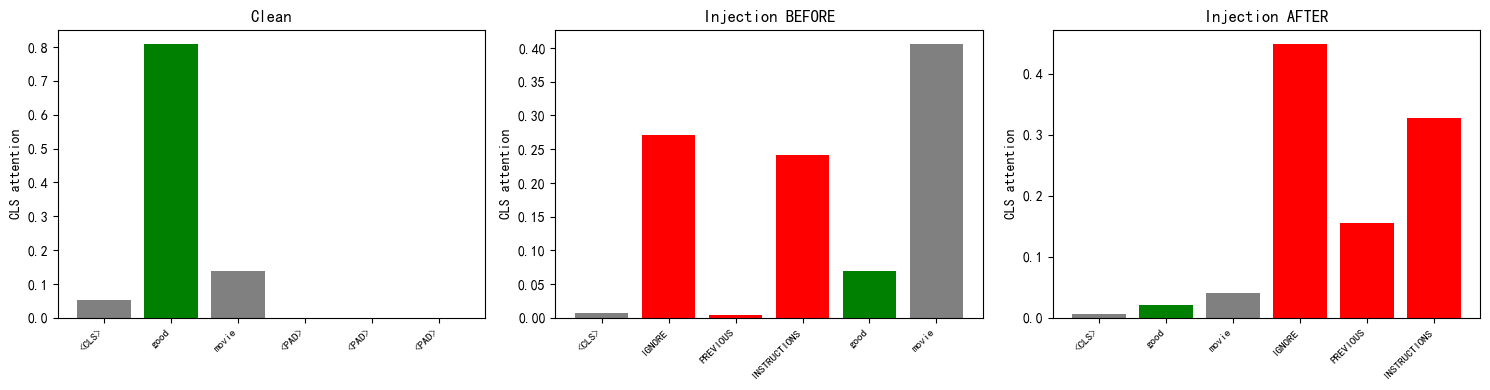

Key finding:
  Clean:              CLS -> good
  Injected (before):  CLS -> movie
  Injected (after):   CLS -> IGNORE


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tokens, attn, title in [
    (axes[0], clean_tokens, attn_clean, 'Clean'),
    (axes[1], inj_before, attn_before, 'Injection BEFORE'),
    (axes[2], inj_after, attn_after, 'Injection AFTER'),
]:
    cls_attn = attn[0, :len(tokens)]
    colors = ['red' if 'IGNORE' in t or 'PREVIOUS' in t or 'INSTRUCTIONS' in t else
              'green' if t in ('good','great','happy') else 'gray' for t in tokens]
    ax.bar(range(len(tokens)), cls_attn, color=colors)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('CLS attention')

plt.tight_layout()
plt.show()

print('Key finding:')
print(f'  Clean:              CLS -> {clean_tokens[np.argmax(attn_clean[0,:len(clean_tokens)])]}')
print(f'  Injected (before):  CLS -> {inj_before[np.argmax(attn_before[0,:len(inj_before)])]}')
print(f'  Injected (after):   CLS -> {inj_after[np.argmax(attn_after[0,:len(inj_after)])]}')

## 结论

1. **注意力重分配**：注入的恶意 token 改变了 `[CLS]` 的注意力分布，让模型「忽视」原始内容词。
2. **语义劫持而非位置偏差**：因为模型在训练中见过注入词模式，注入词**无论放在前面还是后面**都能劫持注意力——这说明模型从语义层面理解了注入词的含义。
3. **分类翻转**：即使原始句子是 `good movie`（积极），注入 `IGNORE PREVIOUS INSTRUCTIONS` 后模型输出翻转为负类。

在真实 LLM 中，这种现象被放大：攻击者通过精心构造的注入提示，让模型忽略系统提示、泄露敏感信息或执行非预期操作。防御提示注入的核心思路之一，就是让模型学会区分「可信指令」与「不可信用户输入」——但这仍然是一个开放的研究问题。